# 10 MLP HPO Comparison and Multi-Seed Confirmation

Compares controlled screening, Random Search and GA using validation evidence only. Confirmation uses seeds [42, 123, 2026].


## 1. Package Setup


In [1]:
# Purpose: Package installs are documented but not run automatically during this static refactor.
# %pip install tensorflow scikit-learn pandas numpy matplotlib seaborn joblib soundfile librosa


## 2. Load Cache and Artifacts


In [2]:
import os
from pathlib import Path

# Purpose: Mounts Google Drive when this notebook is running in Google Colab.
# Why this exists: the project files, cached MFCC features, manifests, models, figures,
# and metric outputs live in Google Drive during Colab runs. The /content/drive path
# only represents the real MyDrive files after drive.mount("/content/drive") succeeds.
# Important: the project root should be the folder that contains Data, Model Variants,
# and outputs. For this project, that expected Colab folder is the INM701 folder below.
COLAB_DRIVE_MOUNT_POINT = Path("/content/drive")
EXPECTED_COLAB_PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/Education/INM701")

try:
    from google.colab import drive

    drive.mount(str(COLAB_DRIVE_MOUNT_POINT))
    print("Google Colab detected. Google Drive mounted.")

    current_project_root = os.environ.get("INTRO_AI_PROJECT_ROOT")
    current_data_dir_exists = bool(current_project_root) and (Path(current_project_root) / "Data").exists()
    expected_data_dir_exists = (EXPECTED_COLAB_PROJECT_ROOT / "Data").exists()

    # Purpose: Keep a valid user-provided project root, but repair stale runtime state
    # if a previous cell pointed INTRO_AI_PROJECT_ROOT somewhere that does not contain Data.
    if current_data_dir_exists:
        print("INTRO_AI_PROJECT_ROOT already points to a folder with Data, so it was kept.")
    elif expected_data_dir_exists:
        os.environ["INTRO_AI_PROJECT_ROOT"] = str(EXPECTED_COLAB_PROJECT_ROOT)
        print("INTRO_AI_PROJECT_ROOT set to the expected INM701 project folder.")
    elif not current_project_root:
        os.environ["INTRO_AI_PROJECT_ROOT"] = str(EXPECTED_COLAB_PROJECT_ROOT)
        print("INTRO_AI_PROJECT_ROOT was not set, so it now points to the expected INM701 folder.")
    else:
        print("INTRO_AI_PROJECT_ROOT was kept, but Data was not found there or in the expected INM701 folder.")
except Exception as exc:
    print("Google Colab Drive mount skipped. This is expected outside Colab.")
    print("Mount skip reason:", exc)

active_project_root = os.environ.get("INTRO_AI_PROJECT_ROOT", "not set")
print("INTRO_AI_PROJECT_ROOT:", active_project_root)
if active_project_root != "not set":
    active_project_root = Path(active_project_root)
    print("Project root exists:", active_project_root.exists())
    print("Expected Data folder:", active_project_root / "Data")
    print("Data folder exists:", (active_project_root / "Data").exists())


Mounted at /content/drive
Google Colab detected. Google Drive mounted.
INTRO_AI_PROJECT_ROOT set to the expected INM701 project folder.
INTRO_AI_PROJECT_ROOT: /content/drive/MyDrive/Colab Notebooks/Education/INM701
Project root exists: True
Expected Data folder: /content/drive/MyDrive/Colab Notebooks/Education/INM701/Data
Data folder exists: True


In [3]:
# Purpose: Later notebooks load the one MLP-ready cache made by notebook 00. They do not
# rescan folders, regenerate splits, extract MFCCs, fit scalers, or recalculate class weights.
import hashlib
import json
import os
import random
import time
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential

try:
    from IPython.display import display
except Exception:
    display = print

RANDOM_STATE = 42
MAX_EPOCHS = 50
EARLY_STOP_PATIENCE = 7
EARLY_STOP_MIN_DELTA = 1e-4
THRESHOLD = 0.5
CLASS_NAMES = {0: "bona_fide", 1: "synthetic"}
CONFIRMATION_SEEDS = [42, 123, 2026]


def resolve_project_root():
    # Purpose: default path.
    explicit = os.environ.get("INTRO_AI_PROJECT_ROOT")
    if explicit:
        return Path(explicit).expanduser().resolve()
    cwd = Path.cwd().resolve()
    # Purpose: Runs each candidate configuration under the same data split for a fair validation comparison.
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "Model Variants").exists():
            return candidate
        if (candidate / "Training" / "Model Variants").exists():
            return candidate / "Training"
    return Path("/content/drive/MyDrive/Colab Notebooks/Education/INM701")


# Purpose: Centralizes filesystem paths so dataset inputs, caches, figures, models, and metric tables are easy
# Purpose: to trace.
PROJECT_ROOT = resolve_project_root()
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "mlp"
CACHE_DIR = OUTPUT_DIR / "cache"
MANIFESTS_DIR = OUTPUT_DIR / "manifests"
CONFIGS_DIR = OUTPUT_DIR / "configs"
TABLES_DIR = OUTPUT_DIR / "tables"
HISTORIES_DIR = OUTPUT_DIR / "histories"
METRICS_DIR = OUTPUT_DIR / "metrics"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"
PILOT_LEGACY_DIR = OUTPUT_DIR / "pilot_legacy"
# Purpose: Creates each output directory before later cells try to save tables, figures, or models.
for directory in [OUTPUT_DIR, CACHE_DIR, MANIFESTS_DIR, CONFIGS_DIR, TABLES_DIR, HISTORIES_DIR, METRICS_DIR, FIGURES_DIR, MODELS_DIR, PILOT_LEGACY_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def require_file(path):
    # Purpose: Stops the notebook early with a clear message when a required upstream artifact is missing.
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}")
    return path


def load_json(path):
    # Purpose: Keeps the load_json helper isolated so later notebook cells can call it consistently.
    with open(require_file(path), "r", encoding="utf-8") as f:
        return json.load(f)


def save_json(payload, path):
    # Purpose: Keeps the save_json helper isolated so later notebook cells can call it consistently.
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)


def load_class_weights():
    # Purpose: Keeps the load_class_weights helper isolated so later notebook cells can call it consistently.
    payload = load_json(CONFIGS_DIR / "class_weights.json")
    weights = payload.get("class_weights", payload)
    return {int(label): float(weight) for label, weight in weights.items()}


for required in [
    CACHE_DIR / "X_train.npy",
    CACHE_DIR / "y_train.npy",
    CACHE_DIR / "train_metadata.csv",
    CACHE_DIR / "X_validation.npy",
    CACHE_DIR / "y_validation.npy",
    CACHE_DIR / "validation_metadata.csv",
    CACHE_DIR / "feature_config.json",
    CONFIGS_DIR / "class_weights.json",
]:
    require_file(required)

X_train = np.load(CACHE_DIR / "X_train.npy")
y_train = np.load(CACHE_DIR / "y_train.npy")
train_metadata = pd.read_csv(CACHE_DIR / "train_metadata.csv")
X_validation = np.load(CACHE_DIR / "X_validation.npy")
y_validation = np.load(CACHE_DIR / "y_validation.npy")
validation_metadata = pd.read_csv(CACHE_DIR / "validation_metadata.csv")
feature_config = load_json(CACHE_DIR / "feature_config.json")
CLASS_WEIGHTS = load_class_weights()

if len(X_train) != len(y_train) or len(X_train) != len(train_metadata):
    raise RuntimeError("Training cache arrays, labels and metadata are not row-aligned.")
if len(X_validation) != len(y_validation) or len(X_validation) != len(validation_metadata):
    raise RuntimeError("Validation cache arrays, labels and metadata are not row-aligned.")

print("Loaded MLP cache:", CACHE_DIR)
print("X_train shape:", X_train.shape)
print("X_validation shape:", X_validation.shape)

selected_hyperparameters_path = CONFIGS_DIR / "selected_hyperparameters.json"


Loaded MLP cache: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/mlp/cache
X_train shape: (9060, 80)
X_validation shape: (1942, 80)


## 3. Keras Utilities


In [4]:
# Purpose: Shared beginner-readable Keras utilities for validation-only model selection.
def normalise_config(config):
    # Purpose: Keeps the normalise_config helper isolated so later notebook cells can call it consistently.
    normalised = dict(config)
    normalised["hidden_units"] = [int(value) for value in normalised["hidden_units"]]
    normalised["activation"] = str(normalised["activation"])
    normalised["optimizer"] = str(normalised["optimizer"])
    normalised["dropout"] = float(normalised["dropout"])
    normalised["learning_rate"] = float(normalised["learning_rate"])
    normalised["batch_size"] = int(normalised["batch_size"])
    normalised["loss"] = normalised.get("loss", "binary_crossentropy")
    normalised["threshold"] = float(normalised.get("threshold", THRESHOLD))
    return normalised


def config_json(config):
    # Purpose: Keeps the config_json helper isolated so later notebook cells can call it consistently.
    return json.dumps(normalise_config(config), sort_keys=True)


def config_key(config):
    # Purpose: Keeps the config_key helper isolated so later notebook cells can call it consistently.
    return hashlib.sha256(config_json(config).encode("utf-8")).hexdigest()


def seed_from_config(config, base_seed=RANDOM_STATE):
    # Purpose: Keeps the seed_from_config helper isolated so later notebook cells can call it consistently.
    digest = hashlib.sha256(f"{base_seed}:{config_json(config)}".encode("utf-8")).hexdigest()
    return int(digest[:8], 16) % (2**31 - 1)


def set_global_seed(seed):
    # Purpose: Keeps the set_global_seed helper isolated so later notebook cells can call it consistently.
    random.seed(int(seed))
    np.random.seed(int(seed))
    tf.keras.utils.set_random_seed(int(seed))
    os.environ["PYTHONHASHSEED"] = str(int(seed))


def make_optimizer(config):
    # Purpose: Keeps the make_optimizer helper isolated so later notebook cells can call it consistently.
    name = str(config["optimizer"]).lower()
    lr = float(config["learning_rate"])
    if name == "adam":
        return tf.keras.optimizers.Adam(learning_rate=lr)
    if name == "rmsprop":
        return tf.keras.optimizers.RMSprop(learning_rate=lr)
    if name in ["sgd", "sgd_momentum"]:
        return tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    raise ValueError(f"Unsupported optimizer: {config['optimizer']}")


def build_mlp_model(config, input_dim):
    # Purpose: Constructs the MLP architecture for the current experiment configuration.
    config = normalise_config(config)
    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    # Purpose: Iterates over this collection to build the next table, feature set, or experiment result
    # Purpose: consistently.
    for units in config["hidden_units"]:
        model.add(Dense(units, activation=config["activation"]))
        if config["dropout"] > 0:
            model.add(Dropout(config["dropout"]))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(loss=config["loss"], optimizer=make_optimizer(config), metrics=["accuracy"])
    return model


def train_and_evaluate_config(config, run_seed, run_name, verbose=0):
    # Purpose: consistently.
    config = normalise_config(config)
    tf.keras.backend.clear_session()
    set_global_seed(run_seed)
    model = build_mlp_model(config, X_train.shape[1])
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=EARLY_STOP_PATIENCE,
            min_delta=EARLY_STOP_MIN_DELTA,
            restore_best_weights=True,
        )
    ]
    start = time.perf_counter()
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_validation, y_validation),
        epochs=MAX_EPOCHS,
        batch_size=config["batch_size"],
        class_weight=CLASS_WEIGHTS,
        callbacks=callbacks,
        verbose=verbose,
    )
    runtime = time.perf_counter() - start
    probability = model.predict(X_validation, batch_size=config["batch_size"], verbose=0).ravel()
    pred = (probability >= config["threshold"]).astype(int)
    row = {
        "configuration": config,
        "config_json": config_json(config),
        "config_key": config_key(config),
        "seed": int(run_seed),
        "validation_macro_f1": float(f1_score(y_validation, pred, average="macro", zero_division=0)),
        "validation_binary_f1_synthetic": float(f1_score(y_validation, pred, pos_label=1, zero_division=0)),
        "validation_accuracy": float(accuracy_score(y_validation, pred)),
        "validation_precision_synthetic": float(precision_score(y_validation, pred, pos_label=1, zero_division=0)),
        "validation_recall_synthetic": float(recall_score(y_validation, pred, pos_label=1, zero_division=0)),
        "best_validation_loss": float(np.min(history.history["val_loss"])),
        "best_epoch": int(np.argmin(history.history["val_loss"]) + 1),
        "epochs_trained": int(len(history.history["loss"])),
        "runtime_seconds": float(runtime),
        "run_name": run_name,
    }
    history_df = pd.DataFrame(history.history)
    history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
    return row, history_df


def flat_result(row, extra=None):
    # Purpose: Keeps the flat_result helper isolated so later notebook cells can call it consistently.
    extra = extra or {}
    config = normalise_config(row["configuration"])
    flat = dict(extra)
    flat.update({
        "hidden_units": json.dumps(config["hidden_units"]),
        "activation": config["activation"],
        "optimizer": config["optimizer"],
        "dropout": config["dropout"],
        "learning_rate": config["learning_rate"],
        "batch_size": config["batch_size"],
        "loss": config["loss"],
        "threshold": config["threshold"],
        "config_json": row["config_json"],
        "config_key": row["config_key"],
        "seed": row["seed"],
        "validation_macro_f1": row["validation_macro_f1"],
        "validation_binary_f1_synthetic": row["validation_binary_f1_synthetic"],
        "validation_accuracy": row["validation_accuracy"],
        "validation_precision_synthetic": row["validation_precision_synthetic"],
        "validation_recall_synthetic": row["validation_recall_synthetic"],
        "best_validation_loss": row["best_validation_loss"],
        "best_epoch": row["best_epoch"],
        "epochs_trained": row["epochs_trained"],
        "runtime_seconds": row["runtime_seconds"],
    })
    return flat


def select_best(rows):
    # Purpose: Keeps the select_best helper isolated so later notebook cells can call it consistently.
    return max(rows, key=lambda row: (row["validation_macro_f1"], -row["best_validation_loss"]))


## 4. Compare HPO Methods


In [5]:
# Purpose: 4. Compare HPO Methods.
controlled_path = CONFIGS_DIR / "controlled_selected_config.json"
random_path = TABLES_DIR / "08_random_search_trials.csv"
ga_path = TABLES_DIR / "09_genetic_algorithm_trials.csv"
def load_trials(path, method):
    # Purpose: Keeps the load_trials helper isolated so later notebook cells can call it consistently.
    if not path.exists():
        print("Missing", method, path, "[RESULT TO BE INSERTED AFTER FINAL RUN]")
        return pd.DataFrame()
    df = pd.read_csv(path)
    df["method"] = method
    return df
def summarise(df, method):
    # Purpose: Keeps the summarise helper isolated so later notebook cells can call it consistently.
    if df.empty:
        return None
    unique_df = df.drop_duplicates("config_key") if "config_key" in df.columns else df
    best = unique_df.sort_values(["validation_macro_f1", "best_validation_loss"], ascending=[False, True]).iloc[0]
    return {"method": method, "best_validation_macro_f1": float(best["validation_macro_f1"]), "best_validation_loss": float(best["best_validation_loss"]), "best_configuration": best["config_json"], "unique_evaluations": int(unique_df["config_key"].nunique()), "evaluation_number_where_best_was_found": int(best.get("unique_evaluation_number", 1)), "total_search_runtime_seconds": float(unique_df["runtime_seconds"].sum())}
random_df = load_trials(random_path, "random_search")
ga_df = load_trials(ga_path, "genetic_algorithm")
rows = []
if controlled_path.exists():
    controlled = load_json(controlled_path)
    rows.append({"method": "controlled_screening", "best_configuration": json.dumps(controlled, sort_keys=True), "best_validation_macro_f1": controlled.get("validation_macro_f1"), "best_validation_loss": controlled.get("best_validation_loss"), "unique_evaluations": "controlled screens"})
else:
    controlled = None
# Purpose: Processes one manifest row at a time so every audio file receives one feature vector and label.
for row in [summarise(random_df, "random_search"), summarise(ga_df, "genetic_algorithm")]:
    if row:
        rows.append(row)
if rows:
    comparison_df = pd.DataFrame(rows)
    # Purpose: Saves the generated artifacts so later notebooks, reports, or reruns can inspect the same
    # Purpose: outputs.
    comparison_df.to_csv(TABLES_DIR / "10_hpo_comparison.csv", index=False)
    display(comparison_df)


,method,best_configuration,best_validation_macro_f1,best_validation_loss,unique_evaluations,evaluation_number_where_best_was_found,total_search_runtime_seconds
0,controlled_screening,"{""activation"": ""elu"", ""batch_size"": 128, ""best...",0.970229,0.075649,controlled screens,NaN,NaN
1,random_search,"{""activation"": ""relu"", ""batch_size"": 128, ""dro...",0.968317,0.085803,40,26.0,373.673736
2,genetic_algorithm,"{""activation"": ""elu"", ""batch_size"": 128, ""drop...",0.968929,0.076347,40,11.0,646.390100


## 5. Convergence Plot


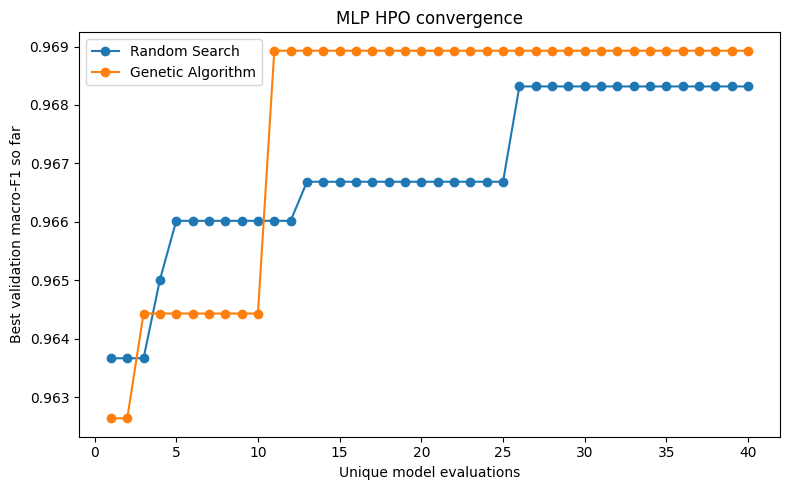

In [6]:
# Purpose: 5. Convergence Plot.
if not random_df.empty or not ga_df.empty:
    plt.figure(figsize=(8, 5))
    # Purpose: Iterates over this collection to build the next table, feature set, or experiment result
    # Purpose: consistently.
    for label, df in [("Random Search", random_df), ("Genetic Algorithm", ga_df)]:
        if df.empty:
            continue
        unique_df = df.drop_duplicates("config_key").sort_values("unique_evaluation_number")
        unique_df["best_macro_f1_so_far"] = unique_df["validation_macro_f1"].cummax()
        plt.plot(unique_df["unique_evaluation_number"], unique_df["best_macro_f1_so_far"], marker="o", label=label)
    plt.xlabel("Unique model evaluations")
    plt.ylabel("Best validation macro-F1 so far")
    plt.title("MLP HPO convergence")
    plt.legend()
    plt.tight_layout()
    # Purpose: Saves the generated artifacts so later notebooks, reports, or reruns can inspect the same
    # Purpose: outputs.
    plt.savefig(FIGURES_DIR / "10_mlp_hpo_convergence.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Convergence plot waits for HPO trial files.")


## 6. Multi-Seed Confirmation


In [7]:
# Purpose: Runs multi-seed confirmation when enabled. If confirmation is not run, this
# cell can still rebuild selected_hyperparameters.json from existing validation-only HPO
# evidence so notebook 11 has a stable handoff file.
RUN_CONFIRMATION = True
confirmation_results_path = TABLES_DIR / "10_confirmation_results.csv"
confirmation_summary_path = TABLES_DIR / "10_confirmation_summary.csv"

def row_config(row):
    # Purpose: Parses a config_json field from a result row back into the normal MLP config
    # dictionary used by the model-building helper.
    return normalise_config(json.loads(row["best_configuration"] if "best_configuration" in row else row["config_json"]))

def selected_payload_from_validation_evidence(source_method, config, validation_macro_f1, best_validation_loss, extra=None):
    # Purpose: Packages the selected configuration in the same shape expected by the final
    # selected-model notebook, without using held-out test metrics.
    payload = {
        "configuration": normalise_config(config),
        "source_method": source_method,
        "selection_metric": "validation_macro_f1",
        "validation_macro_f1": float(validation_macro_f1),
        "best_validation_loss": float(best_validation_loss),
        "test_metrics_used_for_selection": False,
    }
    if extra:
        payload.update(extra)
    return payload

def rebuild_selected_hyperparameters_from_confirmation():
    # Purpose: Recreates selected_hyperparameters.json from existing multi-seed confirmation
    # tables when those tables exist but the JSON handoff file is missing.
    if not confirmation_results_path.exists() or not confirmation_summary_path.exists():
        return None

    confirmation_df = pd.read_csv(confirmation_results_path)
    summary_df = pd.read_csv(confirmation_summary_path)
    if confirmation_df.empty or summary_df.empty:
        return None

    best_summary = summary_df.sort_values(["mean_validation_macro_f1", "mean_validation_loss"], ascending=[False, True]).iloc[0]
    source_method = best_summary["source_method"]
    method_rows = confirmation_df[confirmation_df["source_method"] == source_method]
    if method_rows.empty:
        return None
    best_row = method_rows.sort_values(["validation_macro_f1", "best_validation_loss"], ascending=[False, True]).iloc[0]
    payload = {
        "configuration": normalise_config(json.loads(best_row["config_json"])),
        "source_method": source_method,
        "confirmation_seeds": CONFIRMATION_SEEDS,
        "mean_validation_macro_f1": float(best_summary["mean_validation_macro_f1"]),
        "std_validation_macro_f1": float(best_summary["std_validation_macro_f1"]),
        "mean_validation_loss": float(best_summary["mean_validation_loss"]),
        "std_validation_loss": float(best_summary["std_validation_loss"]),
        "selection_metric": "validation_macro_f1",
        "test_metrics_used_for_selection": False,
        "rebuilt_from_confirmation_tables": True,
    }
    save_json(payload, selected_hyperparameters_path)
    print("Rebuilt selected hyperparameters from confirmation tables:", selected_hyperparameters_path)
    return payload

def rebuild_selected_hyperparameters_from_hpo_evidence():
    # Purpose: Falls back to the best available validation-only HPO evidence when confirmation
    # has not been run yet. This keeps the notebook chain usable without touching the test set.
    candidates = []
    if controlled is not None:
        candidates.append({
            "source_method": "controlled_screening",
            "configuration": normalise_config(controlled),
            "validation_macro_f1": controlled.get("validation_macro_f1"),
            "best_validation_loss": controlled.get("best_validation_loss"),
        })
    if not random_df.empty:
        random_summary = summarise(random_df, "random_search")
        if random_summary:
            candidates.append({
                "source_method": "random_search",
                "configuration": row_config(random_summary),
                "validation_macro_f1": random_summary["best_validation_macro_f1"],
                "best_validation_loss": random_summary["best_validation_loss"],
            })
    if not ga_df.empty:
        ga_summary = summarise(ga_df, "genetic_algorithm")
        if ga_summary:
            candidates.append({
                "source_method": "genetic_algorithm",
                "configuration": row_config(ga_summary),
                "validation_macro_f1": ga_summary["best_validation_macro_f1"],
                "best_validation_loss": ga_summary["best_validation_loss"],
            })

    comparison_path = TABLES_DIR / "10_hpo_comparison.csv"
    if not candidates and comparison_path.exists():
        comparison_df = pd.read_csv(comparison_path)
        if not comparison_df.empty:
            best_comparison = comparison_df.sort_values(["best_validation_macro_f1", "best_validation_loss"], ascending=[False, True]).iloc[0]
            candidates.append({
                "source_method": best_comparison["method"],
                "configuration": row_config(best_comparison),
                "validation_macro_f1": best_comparison["best_validation_macro_f1"],
                "best_validation_loss": best_comparison["best_validation_loss"],
            })

    candidates = [candidate for candidate in candidates if pd.notna(candidate["validation_macro_f1"]) and pd.notna(candidate["best_validation_loss"])]
    if not candidates:
        return None

    best_candidate = sorted(candidates, key=lambda item: (item["validation_macro_f1"], -item["best_validation_loss"]), reverse=True)[0]
    payload = selected_payload_from_validation_evidence(
        best_candidate["source_method"],
        best_candidate["configuration"],
        best_candidate["validation_macro_f1"],
        best_candidate["best_validation_loss"],
        {"confirmation_run": False, "rebuilt_from_best_available_hpo_evidence": True},
    )
    save_json(payload, selected_hyperparameters_path)
    print("Rebuilt selected hyperparameters from best available validation-only HPO evidence:", selected_hyperparameters_path)
    return payload

if RUN_CONFIRMATION:
    candidates = []
    if controlled is not None:
        candidates.append(("controlled_screening", normalise_config(controlled)))
    if not random_df.empty:
        candidates.append(("random_search", row_config(summarise(random_df, "random_search"))))
    if not ga_df.empty:
        candidates.append(("genetic_algorithm", row_config(summarise(ga_df, "genetic_algorithm"))))

    rows = []
    # Purpose: Repeats each candidate across the fixed confirmation seeds so selection is not
    # based on one lucky validation run.
    for method, config in candidates:
        for seed in CONFIRMATION_SEEDS:
            row, _ = train_and_evaluate_config(config, seed, f"10_confirmation_{method}_{seed}", verbose=2)
            rows.append(flat_result(row, {"source_method": method, "confirmation_seed": seed}))
    confirmation_df = pd.DataFrame(rows)
    confirmation_df.to_csv(confirmation_results_path, index=False)
    summary_df = confirmation_df.groupby("source_method").agg(mean_validation_macro_f1=("validation_macro_f1", "mean"), std_validation_macro_f1=("validation_macro_f1", "std"), mean_validation_loss=("best_validation_loss", "mean"), std_validation_loss=("best_validation_loss", "std")).reset_index().sort_values(["mean_validation_macro_f1", "mean_validation_loss"], ascending=[False, True])
    summary_df.to_csv(confirmation_summary_path, index=False)
    method = summary_df.iloc[0]["source_method"]
    config = [config for candidate_method, config in candidates if candidate_method == method][0]
    payload = {"configuration": config, "source_method": method, "confirmation_seeds": CONFIRMATION_SEEDS, "mean_validation_macro_f1": float(summary_df.iloc[0]["mean_validation_macro_f1"]), "std_validation_macro_f1": float(summary_df.iloc[0]["std_validation_macro_f1"]), "mean_validation_loss": float(summary_df.iloc[0]["mean_validation_loss"]), "std_validation_loss": float(summary_df.iloc[0]["std_validation_loss"]), "selection_metric": "validation_macro_f1", "test_metrics_used_for_selection": False}
    save_json(payload, selected_hyperparameters_path)
elif selected_hyperparameters_path.exists():
    selected_payload = load_json(selected_hyperparameters_path)
    print("Loaded selected hyperparameters:", selected_hyperparameters_path)
else:
    selected_payload = rebuild_selected_hyperparameters_from_confirmation()
    if selected_payload is None:
        selected_payload = rebuild_selected_hyperparameters_from_hpo_evidence()
    if selected_payload is None:
        print("RUN_CONFIRMATION is False. [RESULT TO BE INSERTED AFTER FINAL RUN]")
        print("Missing selected hyperparameters:", selected_hyperparameters_path)
        print("Run notebook 10 confirmation or provide HPO trial/comparison outputs first.")


Epoch 1/50
71/71 - 2s - 25ms/step - accuracy: 0.8659 - loss: 0.2878 - val_accuracy: 0.9217 - val_loss: 0.1987
Epoch 2/50
71/71 - 1s - 8ms/step - accuracy: 0.9152 - loss: 0.1916 - val_accuracy: 0.9325 - val_loss: 0.1676
Epoch 3/50
71/71 - 0s - 6ms/step - accuracy: 0.9302 - loss: 0.1592 - val_accuracy: 0.9403 - val_loss: 0.1513
Epoch 4/50
71/71 - 1s - 10ms/step - accuracy: 0.9375 - loss: 0.1428 - val_accuracy: 0.9475 - val_loss: 0.1320
Epoch 5/50
71/71 - 1s - 8ms/step - accuracy: 0.9430 - loss: 0.1315 - val_accuracy: 0.9516 - val_loss: 0.1238
Epoch 6/50
71/71 - 1s - 8ms/step - accuracy: 0.9487 - loss: 0.1246 - val_accuracy: 0.9552 - val_loss: 0.1142
Epoch 7/50
71/71 - 1s - 9ms/step - accuracy: 0.9520 - loss: 0.1142 - val_accuracy: 0.9583 - val_loss: 0.1129
Epoch 8/50
71/71 - 0s - 4ms/step - accuracy: 0.9524 - loss: 0.1110 - val_accuracy: 0.9588 - val_loss: 0.1070
Epoch 9/50
71/71 - 0s - 4ms/step - accuracy: 0.9579 - loss: 0.1038 - val_accuracy: 0.9583 - val_loss: 0.1081
Epoch 10/50
71/71

## 7. Checks


In [8]:
# Purpose: Runs this notebook step and prints or saves the resulting intermediate output for review.
display(pd.DataFrame([("confirmation_seeds", CONFIRMATION_SEEDS), ("selected_hyperparameters_output", str(selected_hyperparameters_path)), ("test_metrics_computed", False)], columns=["check", "value"]))


,check,value
0,confirmation_seeds,"[42, 123, 2026]"
1,selected_hyperparameters_output,/content/drive/MyDrive/Colab Notebooks/Educati...
2,test_metrics_computed,False
